<a href="https://colab.research.google.com/github/k2herat/basic_ml_hse/blob/task_5/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22homework_05_trees_rf%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 5: Древесные алгоритмы

Задание выполнил(а):

    Алметов Кирилл
    

## Общая информация

__Внимание!__  


* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов
* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [ ]:
import numpy as np

n_k1 = 8
n_k2 = 2

p_k1 = n_k1 / 10
p_k2 = n_k2 / 10

entropy = - (p_k1 * np.log(p_k1) + p_k2 * np.log(p_k2))

entropy_rounded = round(entropy, 2)

print(f"Энтропия: {entropy_rounded}")

Энтропия: 0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [1]:
import numpy as np

n_k1 = 8
n_k2 = 2
total_m = n_k1 + n_k2

p_k1_m = n_k1 / total_m
p_k2_m = n_k2 / total_m
H_Rm = p_k1_m * (1 - p_k1_m) + p_k2_m * (1 - p_k2_m)

H_Rl = 0.0
H_Rr = 0.0

weight_Rl = n_k1 / total_m
weight_Rr = n_k2 / total_m

Q = H_Rm - (weight_Rl * H_Rl + weight_Rr * H_Rr)
Q_rounded = round(Q, 2)

print(f"Критерий информативности: {Q_rounded}")

Критерий информативности: 0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [3]:
values = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]


prediction = sum(values) / len(values)


print(prediction)

40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [4]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы.


**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [7]:
import numpy as np
import pandas as pd
from typing import Union, Tuple

def calculate_criterion(y: np.ndarray, task: str) -> float:
    if task == "classification":
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    else:
        return np.var(y) if len(y) > 0 else 0

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    feature = np.array(feature_vector).flatten()
    target = np.array(target_vector).flatten()

    if feature_type == "real":
        sorted_indices = np.argsort(feature)
        feature_sorted = feature[sorted_indices]
        target_sorted = target[sorted_indices]

        unique_values = np.unique(feature_sorted)
        thresholds = (unique_values[1:] + unique_values[:-1]) / 2
    else:
        thresholds = np.unique(feature)

    if len(thresholds) == 0:
        return np.array([]), np.array([]), None, 0.0

    if feature_type == "real":
        left_mask = feature_sorted[:, None] <= thresholds
    else:
        left_mask = feature[:, None] == thresholds


    left_counts = np.sum(left_mask, axis=0)
    right_counts = len(target) - left_counts

    valid_mask = (left_counts > 0) & (right_counts > 0)
    thresholds = thresholds[valid_mask]
    left_mask = left_mask[:, valid_mask]
    left_counts = left_counts[valid_mask]
    right_counts = right_counts[valid_mask]

    if len(thresholds) == 0:
        return np.array([]), np.array([]), None, 0.0


    left_sums = np.dot(left_mask.T, target)
    left_means = left_sums / left_counts
    left_criteria = np.array([calculate_criterion(target[left_mask[:, i]], task) for i in range(len(thresholds))])
    right_criteria = np.array([calculate_criterion(target[~left_mask[:, i]], task) for i in range(len(thresholds))])

    parent_criterion = calculate_criterion(target, task)
    gains = parent_criterion - (left_counts / len(target)) * left_criteria - (right_counts / len(target)) * right_criteria

    max_gain = np.max(gains)
    best_indices = np.where(gains == max_gain)[0]
    threshold_best = np.min(thresholds[best_indices])
    gini_best = max_gain

    return thresholds, gains, threshold_best, gini_best

Эту функцию можно протестировать на датасете `California`.

In [8]:
from sklearn.datasets import fetch_california_housing

In [9]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

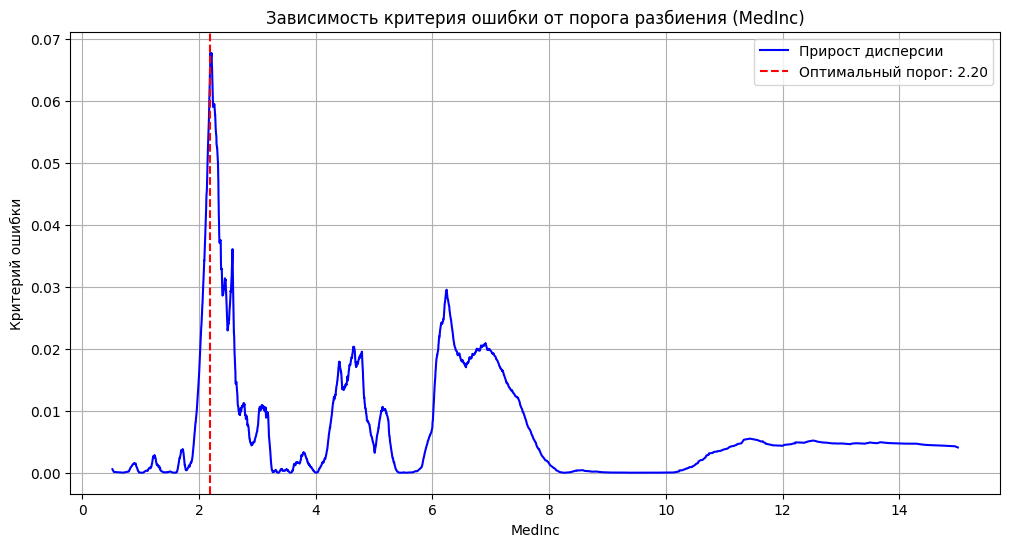

In [13]:

import matplotlib.pyplot as plt



thresholds, gains, best_thr, best_gain = find_best_split(
    feature_vector=X,
    target_vector=y,
    task="regression",
    feature_type="real"
)

plt.figure(figsize=(12, 6))
plt.plot(thresholds, gains, 'b-', label='Прирост дисперсии')
plt.axvline(x=best_thr, color='r', linestyle='--', label=f'Оптимальный порог: {best_thr:.2f}')
plt.xlabel('MedInc')
plt.ylabel('Критерий ошибки')
plt.title('Зависимость критерия ошибки от порога разбиения ')
plt.legend()
plt.grid(True)
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [16]:
thresholds, gains, best_thr, best_gain = find_best_split(
    feature_vector=X,
    target_vector=y,
    task="regression",
    feature_type="real"
)


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции.
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в данных и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [17]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(self, sub_X: np.ndarray, sub_y: np.ndarray, node: dict) -> None:
      if np.all(sub_y == sub_y[0]):
        node["type"] = "terminal"
        node["class"] = sub_y[0]
        return

      feature_best, threshold_best, gini_best, split = None, None, None, None
      for feature in range(sub_X.shape[1]):
        feature_type = self._feature_types[feature]
        categories_map = {}

        if feature_type == "real":
            feature_vector = sub_X[:, feature]
        elif feature_type == "categorical":
            feature_vector = sub_X[:, feature]

        _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

        if gini_best is None or gini > gini_best:
            feature_best = feature
            gini_best = gini

            if feature_type == "real":
                threshold_best = threshold
                split = (sub_X[:, feature] <= threshold)
            elif feature_type == "categorical":
                threshold_best = threshold
                split = (sub_X[:, feature] == threshold)
            else:
                raise ValueError

      if feature_best is None:
        node["type"] = "terminal"
        node["class"] = Counter(sub_y).most_common(1)[0][0]
        return

      node["type"] = "nonterminal"
      node["feature_split"] = feature_best
      if self._feature_types[feature_best] == "real":
          node["threshold"] = threshold_best
      else:
          node["category_split"] = threshold_best


      self._fit_node(sub_X[split], sub_y[split], node["left_child"])
      self._fit_node(sub_X[~split], sub_y[~split], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
      if node["type"] == "terminal":
        return node["class"]

      feature_idx = node["feature_split"]
      feature_type = self._feature_types[feature_idx]

      if feature_type == "real":
        if x[feature_idx] <= node["threshold"]:
          return self._predict_node(x, node["left_child"])
        else:
          return self._predict_node(x, node["right_child"])
      elif feature_type == "categorical":

        if x[feature_idx] == node["category_split"]:
          return self._predict_node(x, node["left_child"])
        else:
          return self._predict_node(x, node["right_child"])

**Задание 2.3 (1 балл)** Загрузите таблицу `STUDENTS` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [18]:
STUDENTS = 'https://www.dropbox.com/scl/fi/hnmqruw6px5wnm4bip2rz/students.csv?rlkey=ee113i30jnxid3sdxf4oipgkw&dl=1'

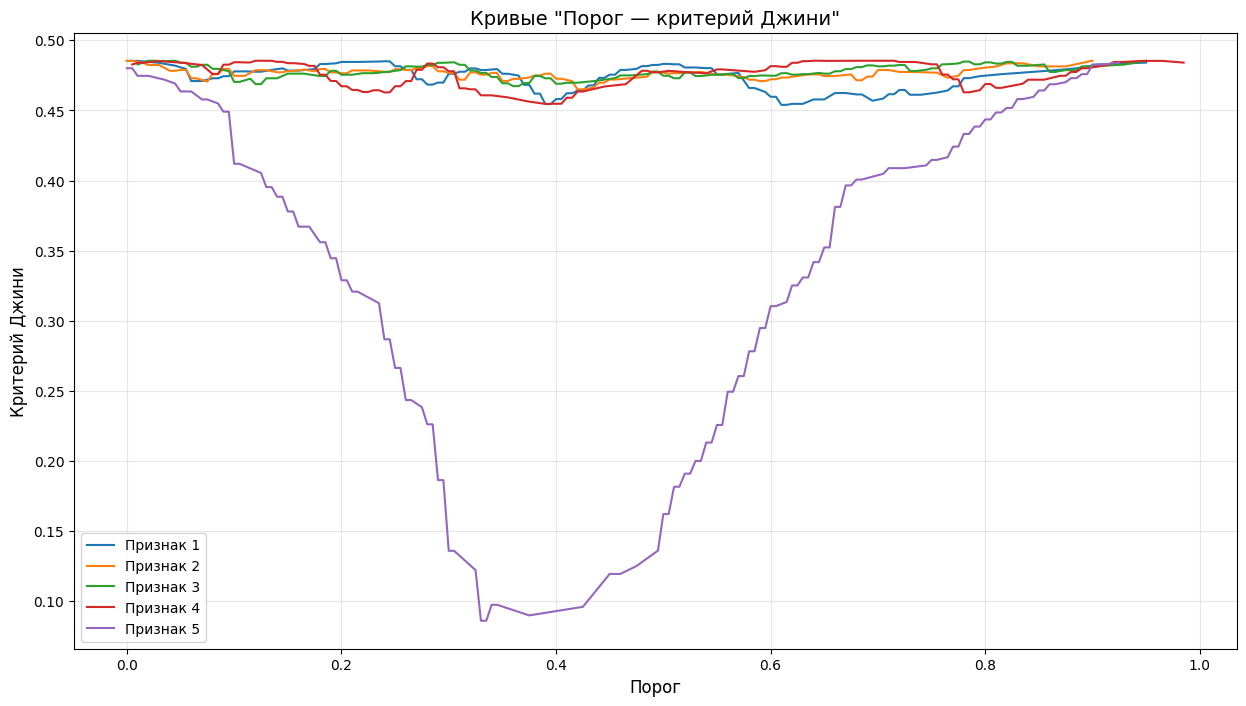

<ipython-input-21-b3c8ae0a40e9>:56: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(features[:, i], target, alpha=0.5, c=target, cmap='viridis')


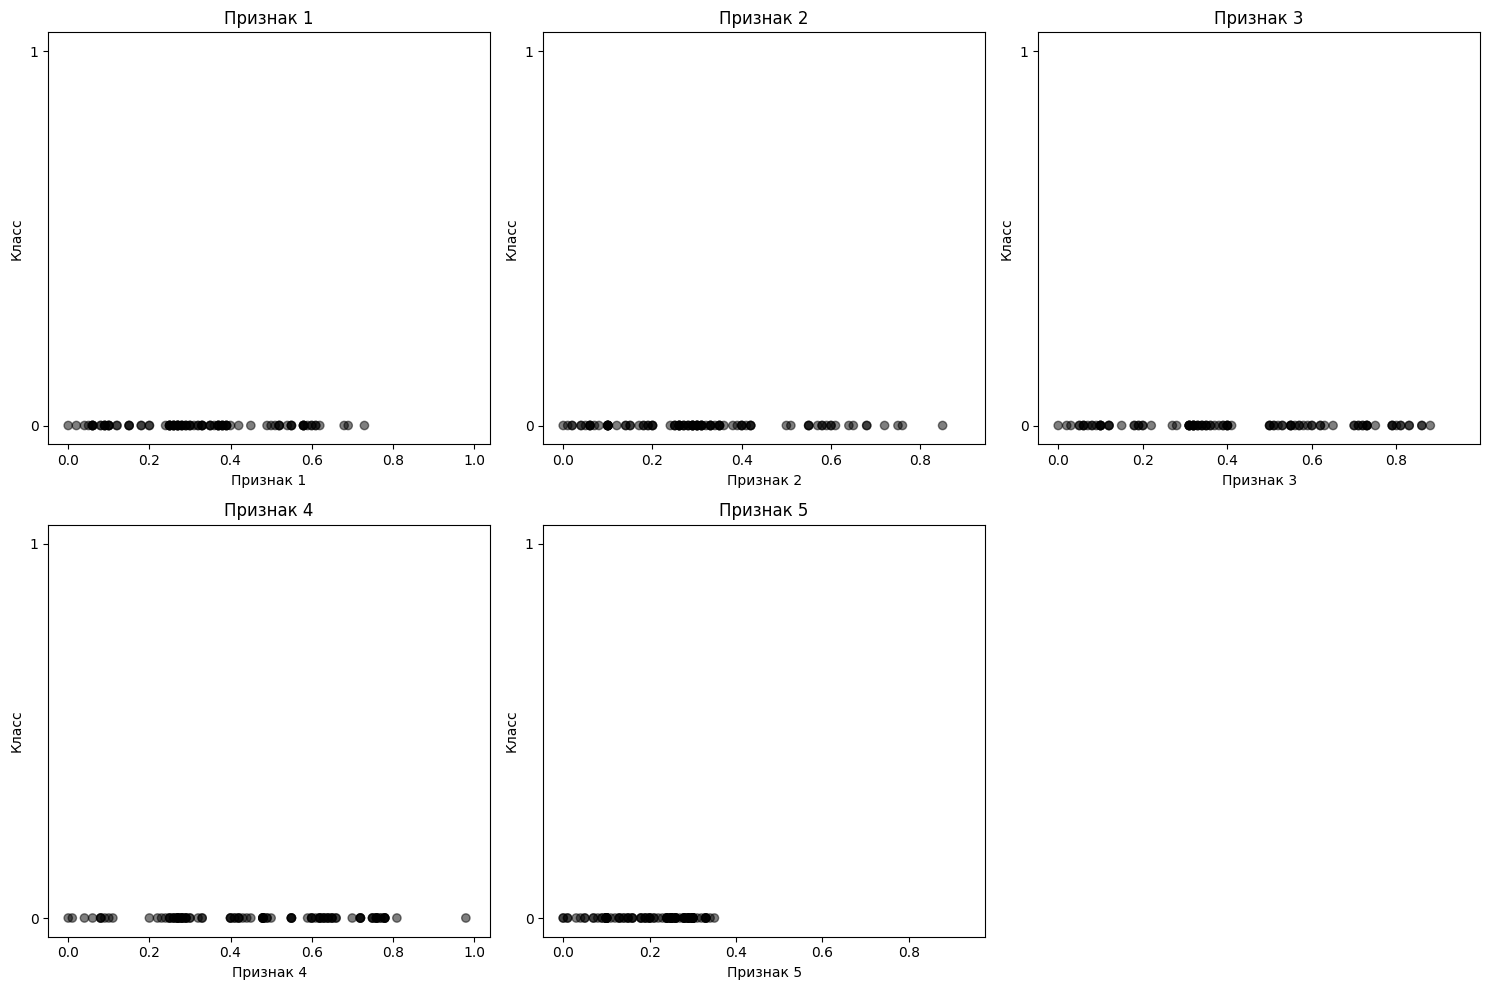

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv(STUDENTS, header=None)

features = data.iloc[:, :5].apply(pd.to_numeric, errors='coerce').values
target = data.iloc[:, 5].values

valid_rows = ~np.isnan(features).any(axis=1)
features = features[valid_rows]
target = target[valid_rows]


def calculate_gini(y_left, y_right):
    def _gini(y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return 1 - np.sum(p ** 2)
    n = len(y_left) + len(y_right)
    if n == 0:
        return 0
    return (len(y_left)/n * _gini(y_left)) + (len(y_right)/n * _gini(y_right))


plt.figure(figsize=(15, 8))
for i in range(5):
    feature = features[:, i]
    sorted_feature = np.sort(feature)
    thresholds = (sorted_feature[1:] + sorted_feature[:-1]) / 2

    gini_values = []
    for thresh in thresholds:
        mask = feature <= thresh
        y_left = target[mask]
        y_right = target[~mask]
        gini = calculate_gini(y_left, y_right)
        gini_values.append(gini)

    plt.plot(thresholds, gini_values, label=f'Признак {i+1}')

plt.xlabel('Порог', fontsize=12)
plt.ylabel('Критерий Джини', fontsize=12)
plt.title('Кривые "Порог — критерий Джини"', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Диаграммы рассеяния
plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.scatter(features[:, i], target, alpha=0.5, c=target, cmap='viridis')
    plt.xlabel(f'Признак {i+1}', fontsize=10)
    plt.ylabel('Класс', fontsize=10)
    plt.title(f'Признак {i+1}', fontsize=12)

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (из датасета),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [29]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [30]:
DIABETES = 'https://www.kaggle.com/api/v1/datasets/download/uciml/pima-indians-diabetes-database'

In [31]:
data = pd.read_csv(DIABETES)
print(f"Dataset shape: {data.shape}")
data.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x83 in position 10: invalid start byte

Посмотрим на распределение целевой переменной

In [28]:
data['Outcome'].hist()
plt.show()

KeyError: 'Outcome'

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

## Котобонус! (0.25 балла)

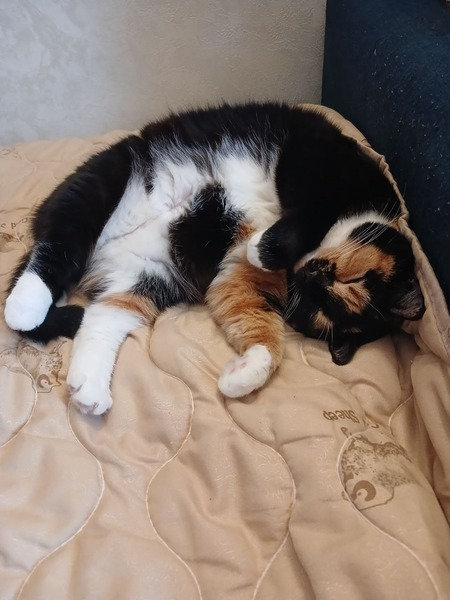

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?